# Modelagem com XGBoost

O objetivo é comparar seu desempenho com a Regressão Logística, explorando a capacidade do XGBoost de capturar relações não lineares e interações entre variáveis.

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report

from xgboost import XGBClassifier

In [23]:
PROJECT_ROOT = Path().resolve().parents[0]

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'credit_score_features.csv'
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(100000, 35)


,Customer_ID,Month,Month_Num,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,target,Loan_Type_Count,Has_Min_Payment_Only,Is_Bad_Credit_Mix,Debt_to_Income_Ratio,EMI_to_Income_Ratio,Invested_to_Income_Ratio,Balance_to_Income_Ratio,Delay_x_Inquiries,Utilization_x_Debt
0,CUS_0x1000,January,1,18,Lawyer,30625.94,2706.161667,6,5,27,...,0,2,1,1,0.051032,0.015868,0.090442,0.093463,620,41592.306407
1,CUS_0x1000,February,2,18,Lawyer,30625.94,2706.161667,6,5,27,...,1,2,1,1,0.051032,0.015868,0.065086,0.115123,682,46011.693758
2,CUS_0x1000,March,3,18,Lawyer,30625.94,2706.161667,6,5,27,...,1,2,1,1,0.051032,0.015868,0.040299,0.136215,682,59837.459708
3,CUS_0x1000,April,4,18,Lawyer,30625.94,2706.161667,6,5,27,...,1,2,1,1,0.051032,0.015868,0.032485,0.155115,704,51330.780120
4,CUS_0x1000,May,5,18,Lawyer,30625.94,2706.161667,6,5,27,...,1,2,1,1,0.051032,0.015868,0.070888,0.113016,737,50529.674519


In [24]:
target_col = 'target'
group_col = 'Customer_ID'

drop_from_model = ['Customer_ID', 'target']

X = df.drop(columns=drop_from_model).copy()
y = df[target_col]
groups = df[group_col]

# Remover variáveis que não valem a pena no XGBoost neste caso
cols_to_drop = ['Type_of_Loan', 'Month']
X = X.drop(columns=cols_to_drop)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print('Variáveis numéricas:', len(numeric_cols))
print('Variáveis categóricas:', len(categorical_cols))
print('Categóricas:', categorical_cols)

Variáveis numéricas: 27
Variáveis categóricas: 4
Categóricas: ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


C:\Users\guilh\AppData\Local\Temp\ipykernel_9724\2492571325.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


## Divisão em treino e teste (Group Split)

Utilizei `GroupShuffleSplit` para separar os dados em treino e teste respeitando os grupos de clientes.

Isso garante que:
- Um mesmo cliente não apareça em ambos os conjuntos
- O modelo não aprenda padrões específicos de um cliente individual

In [25]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
dev_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_dev, X_test = X.iloc[dev_idx].copy(), X.iloc[test_idx].copy()
y_dev, y_test = y.iloc[dev_idx].copy(), y.iloc[test_idx].copy()
groups_dev, groups_test = groups.iloc[dev_idx], groups.iloc[test_idx].copy()

In [26]:
X_dev_model = pd.get_dummies(X_dev, columns=categorical_cols, drop_first=False)
X_test_model = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)

# Garantir mesmas colunas em dev e test
X_dev_model, X_test_model = X_dev_model.align(X_test_model, join='left', axis=1, fill_value=0)

print(X_dev_model.shape, X_test_model.shape)

(80000, 53) (20000, 53)


In [27]:
scale_pos_weight = (y_dev == 0).sum() / (y_dev == 1).sum()

print(f'Taxa positiva em dev: {y_dev.mean():.4f}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Taxa positiva em dev: 0.2909
scale_pos_weight: 2.44


## Tratamento de desbalanceamento

Problemas de crédito geralmente possuem desbalanceamento entre classes.

Calculamos o parâmetro `scale_pos_weight`, que ajusta o peso da classe minoritária (inadimplentes), permitindo que o modelo penalize mais erros nessa classe.

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(X_dev_model, y_dev)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [29]:
y_proba = xgb_baseline.predict_proba(X_test_model)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC AUC: {roc_auc:.4f}')
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

ROC AUC: 0.8802
              precision    recall  f1-score   support

           0     0.9136    0.8081    0.8576     14274
           1     0.6286    0.8095    0.7076      5726

    accuracy                         0.8085     20000
   macro avg     0.7711    0.8088    0.7826     20000
weighted avg     0.8320    0.8085    0.8147     20000



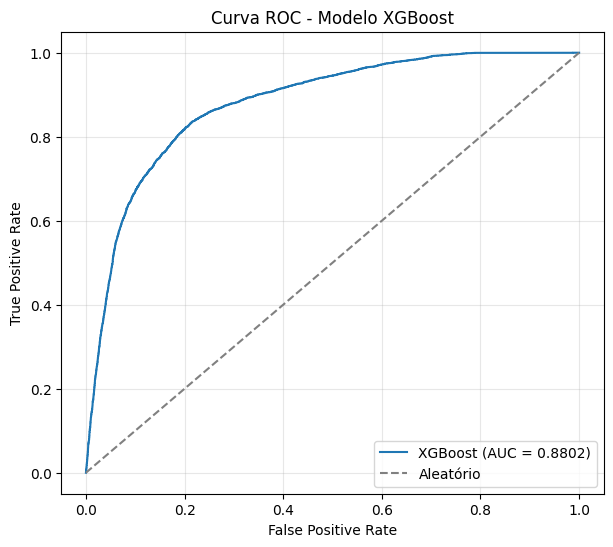

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo XGBoost")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

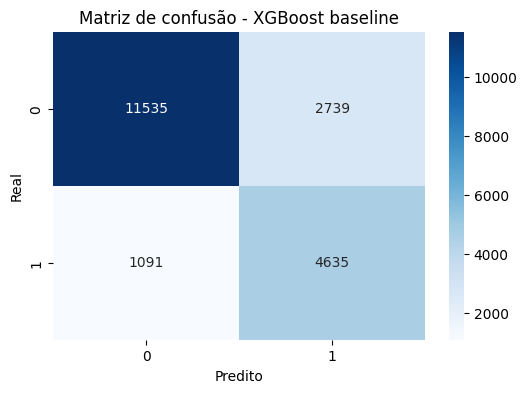

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusão - XGBoost baseline')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [32]:
feat_imp = pd.DataFrame({
    'feature': X_dev_model.columns,
    'importance': xgb_baseline.feature_importances_
}).sort_values('importance', ascending=False)

feat_imp.head(15)

,feature,importance
42,Credit_Mix_Bad,0.214727
12,Outstanding_Debt,0.120927
20,Is_Bad_Credit_Mix,0.091326
44,Credit_Mix_Standard,0.054786
43,Credit_Mix_Good,0.044337
6,Interest_Rate,0.044047
26,Utilization_x_Debt,0.032114
8,Delay_from_due_date,0.025959
5,Num_Credit_Card,0.023047
0,Month_Num,0.022545


## Importância das variáveis

O XGBoost fornece uma medida de importância das variáveis baseada em ganho de informação.

Essa análise permite:

- Entender quais variáveis mais influenciam o modelo
- Identificar possíveis redundâncias
- Gerar insights de negócio

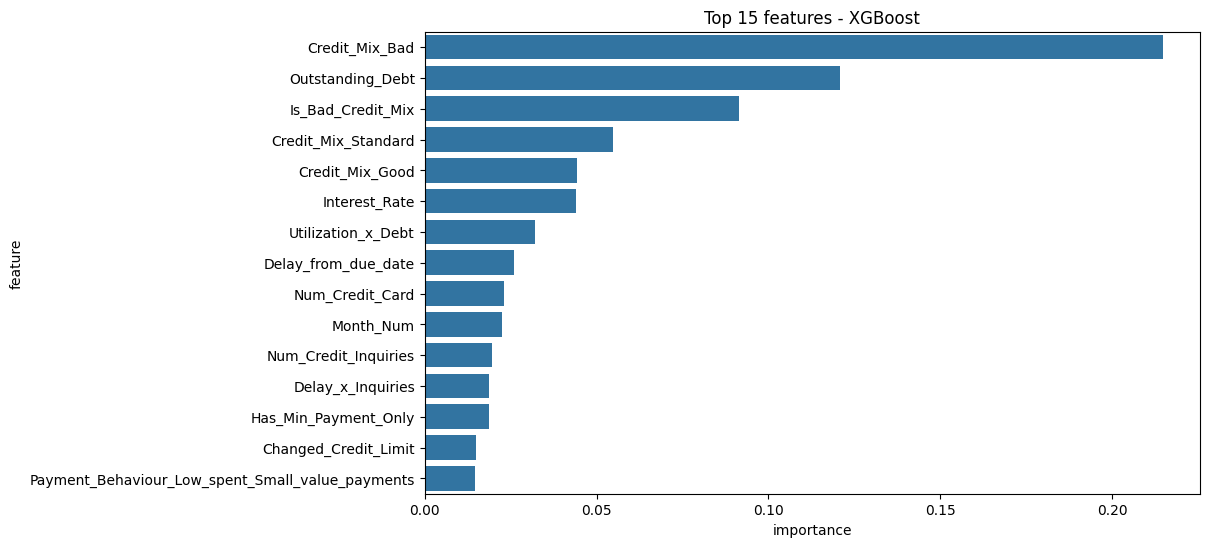

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature')
plt.title('Top 15 features - XGBoost')
plt.show()

# Tunning para encontrar os melhores parametros

In [34]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

param_grid_fast = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5],
    'learning_rate': [0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

gkf = GroupKFold(n_splits=3)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_fast,
    scoring='roc_auc',
    cv=gkf,
    verbose=2,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_dev_model, y_dev, groups=groups_dev)

print("Melhores parâmetros:")
print(grid_search.best_params_)

print(f"\nMelhor ROC AUC médio na validação cruzada: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhores parâmetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Melhor ROC AUC médio na validação cruzada: 0.8741


In [35]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

param_grid_fast = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5],
    'learning_rate': [0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

gkf = GroupKFold(n_splits=3)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_fast,
    scoring='roc_auc',
    cv=gkf,
    verbose=2,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_dev_model, y_dev, groups=groups_dev)

print("Melhores parâmetros:")
print(grid_search.best_params_)

print(f"\nMelhor ROC AUC médio na validação cruzada: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhores parâmetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Melhor ROC AUC médio na validação cruzada: 0.8741


In [36]:
best_xgb = grid_search.best_estimator_
best_xgb

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [37]:
from sklearn.metrics import roc_auc_score

y_proba_tuned = best_xgb.predict_proba(X_test_model)[:, 1]
y_pred_tuned = (y_proba_tuned >= 0.5).astype(int)

roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
print(f"ROC AUC no teste: {roc_auc_tuned:.4f}")

ROC AUC no teste: 0.8802


In [38]:
from sklearn.metrics import classification_report

print("Classification Report - XGBoost Tunado\n")
print(classification_report(y_test, y_pred_tuned, digits=4, zero_division=0))

Classification Report - XGBoost Tunado

              precision    recall  f1-score   support

           0     0.9152    0.8047    0.8564     14274
           1     0.6258    0.8140    0.7076      5726

    accuracy                         0.8074     20000
   macro avg     0.7705    0.8094    0.7820     20000
weighted avg     0.8323    0.8074    0.8138     20000



Porém como o recall (mede a proporção de maus pagadores (positivos reais) que o modelo conseguiu identificar corretamente), deu um valor um pouco melhor, esse modelo de grid será considerado

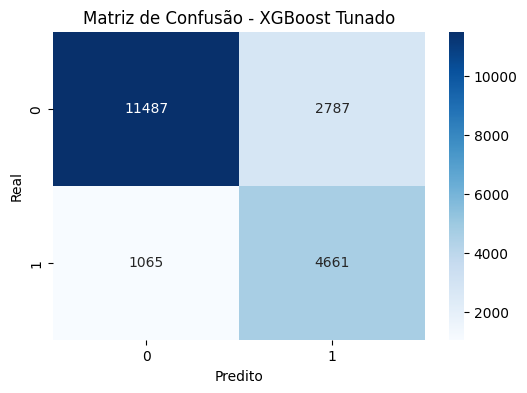

In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - XGBoost Tunado')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

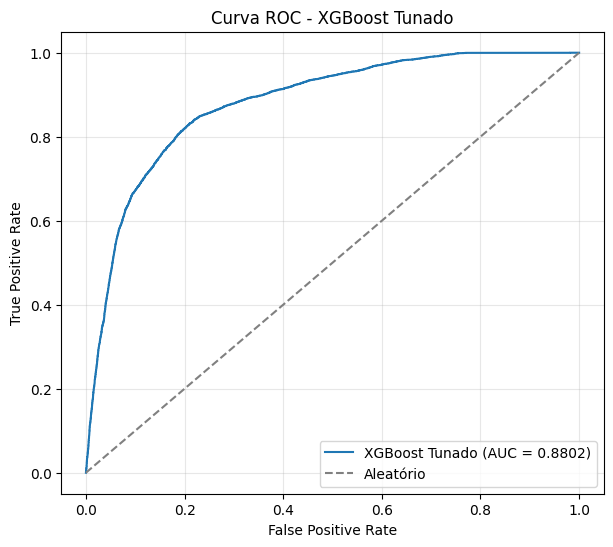

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_test, y_proba_tuned)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)

plt.figure(figsize=(7, 6))
plt.plot(fpr_tuned, tpr_tuned, label=f'XGBoost Tunado (AUC = {auc_tuned:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost Tunado')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

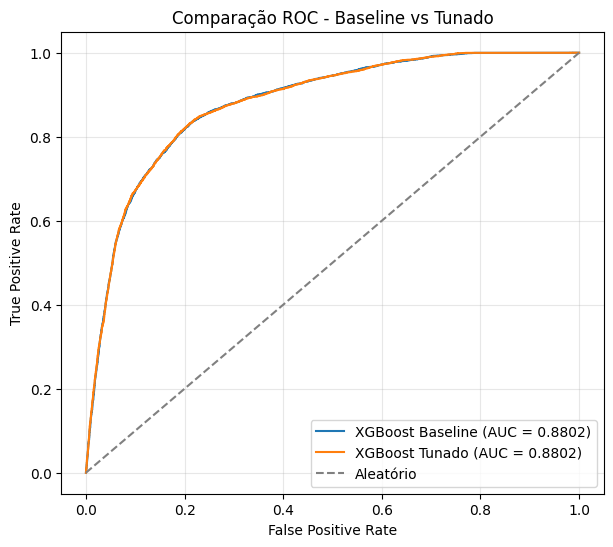

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

# baseline
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba)
auc_base = roc_auc_score(y_test, y_proba)

# tuned
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)

plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, label=f'XGBoost Baseline (AUC = {auc_base:.4f})')
plt.plot(fpr_tuned, tpr_tuned, label=f'XGBoost Tunado (AUC = {auc_tuned:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparação ROC - Baseline vs Tunado')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [42]:
results_comparison = pd.DataFrame({
    'Modelo': ['XGBoost Baseline', 'XGBoost Tunado'],
    'ROC_AUC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_tuned)
    ]
})

results_comparison

,Modelo,ROC_AUC
0,XGBoost Baseline,0.880184
1,XGBoost Tunado,0.880243
